#Imports


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12

#Load Data


In [2]:
# Loading dataset.csv

df = pd.read_csv("Dataset.csv")

print("Shape:", df.shape)
display(df.head())
display(df.info())
display(df.describe(include="all"))

Shape: (8000, 20)


,CustomerID,Age,Gender,Income,CampaignChannel,CampaignType,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,AdvertisingPlatform,AdvertisingTool,Conversion
0,8000,56,Female,136912,Social Media,Awareness,6497.870068,0.043919,0.088031,0,2.399017,7.396803,19,6,9,4,688,IsConfid,ToolConfid,1
1,8001,69,Male,41760,Email,Retention,3898.668606,0.155725,0.182725,42,2.917138,5.352549,5,2,7,2,3459,IsConfid,ToolConfid,1
2,8002,46,Female,88456,PPC,Awareness,1546.429596,0.277490,0.076423,2,8.223619,13.794901,0,11,2,8,2337,IsConfid,ToolConfid,1
3,8003,32,Female,44085,PPC,Conversion,539.525936,0.137611,0.088004,47,4.540939,14.688363,89,2,2,0,2463,IsConfid,ToolConfid,1
4,8004,60,Female,83964,PPC,Conversion,1678.043573,0.252851,0.109940,0,2.046847,13.993370,6,6,6,8,4345,IsConfid,ToolConfid,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CustomerID           8000 non-null   int64  
 1   Age                  8000 non-null   int64  
 2   Gender               8000 non-null   object 
 3   Income               8000 non-null   int64  
 4   CampaignChannel      8000 non-null   object 
 5   CampaignType         8000 non-null   object 
 6   AdSpend              8000 non-null   float64
 7   ClickThroughRate     8000 non-null   float64
 8   ConversionRate       8000 non-null   float64
 9   WebsiteVisits        8000 non-null   int64  
 10  PagesPerVisit        8000 non-null   float64
 11  TimeOnSite           8000 non-null   float64
 12  SocialShares         8000 non-null   int64  
 13  EmailOpens           8000 non-null   int64  
 14  EmailClicks          8000 non-null   int64  
 15  PreviousPurchases    8000 non-null   i

None

,CustomerID,Age,Gender,Income,CampaignChannel,CampaignType,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,AdvertisingPlatform,AdvertisingTool,Conversion
count,8000.00000,8000.000000,8000,8000.000000,8000,8000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000,8000,8000.000000
unique,NaN,NaN,2,NaN,5,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,NaN
top,NaN,NaN,Female,NaN,Referral,Conversion,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,IsConfid,ToolConfid,NaN
freq,NaN,NaN,4839,NaN,1719,2077,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8000,8000,NaN
mean,11999.50000,43.625500,NaN,84664.196750,NaN,NaN,5000.944830,0.154829,0.104389,24.751625,5.549299,7.727718,49.799750,9.476875,4.467375,4.485500,2490.268500,NaN,NaN,0.876500
std,2309.54541,14.902785,NaN,37580.387945,NaN,NaN,2838.038153,0.084007,0.054878,14.312269,2.607358,4.228218,28.901165,5.711111,2.856564,2.888093,1429.527162,NaN,NaN,0.329031
min,8000.00000,18.000000,NaN,20014.000000,NaN,NaN,100.054813,0.010005,0.010018,0.000000,1.000428,0.501669,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,0.000000
25%,9999.75000,31.000000,NaN,51744.500000,NaN,NaN,2523.221165,0.082635,0.056410,13.000000,3.302479,4.068340,25.000000,5.000000,2.000000,2.000000,1254.750000,NaN,NaN,1.000000
50%,11999.50000,43.000000,NaN,84926.500000,NaN,NaN,5013.440044,0.154505,0.104046,25.000000,5.534257,7.682956,50.000000,9.000000,4.000000,4.000000,2497.000000,NaN,NaN,1.000000
75%,13999.25000,56.000000,NaN,116815.750000,NaN,NaN,7407.989369,0.228207,0.152077,37.000000,7.835756,11.481468,75.000000,14.000000,7.000000,7.000000,3702.250000,NaN,NaN,1.000000


#Cleaning


In [3]:
# The raw dataset is already pretty clean, but I still standardize text fields
# and force the numeric columns into the right type so the analysis stays stable
text_cols = ["Gender", "CampaignChannel", "CampaignType", "AdvertisingPlatform", "AdvertisingTool"]
for col in text_cols:
    df[col] = df[col].astype(str).str.strip()

# Make sure the metrics we will aggregate are actually numeric.
num_cols = [
    "Age", "Income", "AdSpend", "ClickThroughRate", "ConversionRate", "WebsiteVisits",
    "PagesPerVisit", "TimeOnSite", "SocialShares", "EmailOpens", "EmailClicks",
    "PreviousPurchases", "LoyaltyPoints", "Conversion"
]
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print("Missing values per column:")
print(df.isna().sum())

Missing values per column:
CustomerID             0
Age                    0
Gender                 0
Income                 0
CampaignChannel        0
CampaignType           0
AdSpend                0
ClickThroughRate       0
ConversionRate         0
WebsiteVisits          0
PagesPerVisit          0
TimeOnSite             0
SocialShares           0
EmailOpens             0
EmailClicks            0
PreviousPurchases      0
LoyaltyPoints          0
AdvertisingPlatform    0
AdvertisingTool        0
Conversion             0
dtype: int64


#Feature Engineering


In [4]:
# The dataset does not give a direct ad-exposure count, so I build a proxy
# from the engagement signals that are most closely related to repeated visibility
df["EstimatedExposure"] = (
    df["WebsiteVisits"] + df["EmailOpens"] + df["EmailClicks"] + df["SocialShares"]
)

# Group exposure into the same bands
def exposure_band(x):
    if x <= 4:
        return "0-4"
    elif x <= 20:
        return "5-20"
    elif x <= 100:
        return "21-100"
    return "100+"

df["ExposureBand"] = df["EstimatedExposure"].apply(exposure_band)

# The first 10% of exposure values are treated as first-time viewers,
# while the rest are grouped as repeated viewers
threshold = df["EstimatedExposure"].quantile(0.10)
df["ViewerType"] = np.where(df["EstimatedExposure"] <= threshold, "First-Time Viewers", "Repeated Viewers")


def duration_bucket(x):
    if x <= 20:
        return "Short-Term (1-3 Days)"
    elif x <= 100:
        return "Medium-Term (1-2 Weeks)"
    return "Long-Term (3+ Weeks)"

df["ExposureDuration"] = df["EstimatedExposure"].apply(duration_bucket)

display(df[["EstimatedExposure", "ExposureBand", "ViewerType", "ExposureDuration"]].head())

,EstimatedExposure,ExposureBand,ViewerType,ExposureDuration
0,34,21-100,First-Time Viewers,Medium-Term (1-2 Weeks)
1,56,21-100,Repeated Viewers,Medium-Term (1-2 Weeks)
2,15,5-20,First-Time Viewers,Short-Term (1-3 Days)
3,140,100+,Repeated Viewers,Long-Term (3+ Weeks)
4,18,5-20,First-Time Viewers,Short-Term (1-3 Days)


In [6]:

def summary_table(group_col, title):
    out = (
        df.groupby(group_col)
        .agg(
            Avg_CTR=("ClickThroughRate", "mean"),
            Avg_ConversionRate=("ConversionRate", "mean"),
            Avg_Conversion=("Conversion", "mean"),
            Avg_AdSpend=("AdSpend", "mean"),
            Count=("CustomerID", "size"),
        )
        .sort_values("Avg_CTR", ascending=False)
    )
    print(f"\n{title}")
    display(out.round(4))
    return out

# Build the tables that later drive the charts and final conclusions.
campaign_type_summary = summary_table("CampaignType", "Campaign Type Summary")
channel_summary = summary_table("CampaignChannel", "Campaign Channel Summary")
exposure_summary = summary_table("ExposureBand", "Exposure Band Summary")
viewer_summary = summary_table("ViewerType", "Viewer Type Summary")
duration_summary = summary_table("ExposureDuration", "Exposure Duration Summary")


Campaign Type Summary


,Avg_CTR,Avg_ConversionRate,Avg_Conversion,Avg_AdSpend,Count
CampaignType,,,,,
Retention,0.1561,0.1032,0.8582,5017.1352,1947
Awareness,0.1558,0.1044,0.8556,5069.3389,1988
Conversion,0.1557,0.1049,0.9336,4959.1127,2077
Consideration,0.1518,0.1051,0.8556,4960.3992,1988



Campaign Channel Summary


,Avg_CTR,Avg_ConversionRate,Avg_Conversion,Avg_AdSpend,Count
CampaignChannel,,,,,
PPC,0.1583,0.1041,0.8828,4954.2217,1655
Email,0.1556,0.1049,0.8703,5055.6043,1557
Social Media,0.1555,0.1066,0.8683,4965.3214,1519
SEO,0.1532,0.1035,0.8768,4994.1315,1550
Referral,0.1517,0.1031,0.8831,5034.0423,1719



Exposure Band Summary


,Avg_CTR,Avg_ConversionRate,Avg_Conversion,Avg_AdSpend,Count
ExposureBand,,,,,
5-20,0.1578,0.1101,0.6753,4665.5010,77
21-100,0.1560,0.1040,0.8719,5041.8197,4880
100+,0.1529,0.1048,0.8889,4943.8827,3043



Viewer Type Summary


,Avg_CTR,Avg_ConversionRate,Avg_Conversion,Avg_AdSpend,Count
ViewerType,,,,,
First-Time Viewers,0.1614,0.1066,0.8384,4958.5414,817
Repeated Viewers,0.1541,0.1041,0.8808,5005.7678,7183



Exposure Duration Summary


,Avg_CTR,Avg_ConversionRate,Avg_Conversion,Avg_AdSpend,Count
ExposureDuration,,,,,
Short-Term (1-3 Days),0.1578,0.1101,0.6753,4665.5010,77
Medium-Term (1-2 Weeks),0.1560,0.1040,0.8719,5041.8197,4880
Long-Term (3+ Weeks),0.1529,0.1048,0.8889,4943.8827,3043


#Findings


In [9]:

print("\nBest exposure range based on grouped metrics:")
display(exposure_summary[["Avg_CTR", "Avg_ConversionRate", "Avg_Conversion", "Count"]].round(4))

print("\nBest campaign type by Conversion Rate:")
display(campaign_type_summary.sort_values("Avg_ConversionRate", ascending=False).head(4).round(4))

print("\nBest campaign type by CTR:")
display(campaign_type_summary.sort_values("Avg_CTR", ascending=False).head(4).round(4))

print("\nBest channel by CTR:")
display(channel_summary.sort_values("Avg_CTR", ascending=False).head(5).round(4))

print("\nBest channel by Conversion Rate:")
display(channel_summary.sort_values("Avg_ConversionRate", ascending=False).head(5).round(4))

# Spend bands are added separately
# The dataset max spend is below 10,000, so the last bin should stop there
df["SpendBand"] = pd.cut(
    df["AdSpend"],
    bins=[0, 1000, 5000, 7500, 9000, 10000],
    labels=["0-1K", "1K-5K", "5K-7.5K", "7.5K-9K", "9K-10K"],
    include_lowest=True
)

spend_summary = (
    df.groupby("SpendBand")
    .agg(
        Avg_CTR=("ClickThroughRate", "mean"),
        Avg_ConversionRate=("ConversionRate", "mean"),
        Avg_Conversion=("Conversion", "mean"),
        Count=("CustomerID", "size"),
    )
    .sort_values("Avg_CTR", ascending=False)
)

print("\nSpend band summary:")
display(spend_summary.round(4))

print("\nViewer type comparison:")
display(viewer_summary[["Avg_CTR", "Avg_ConversionRate", "Avg_Conversion", "Count"]].round(4))


Best exposure range based on grouped metrics:


,Avg_CTR,Avg_ConversionRate,Avg_Conversion,Count
ExposureBand,,,,
5-20,0.1578,0.1101,0.6753,77
21-100,0.1560,0.1040,0.8719,4880
100+,0.1529,0.1048,0.8889,3043



Best campaign type by Conversion Rate:


,Avg_CTR,Avg_ConversionRate,Avg_Conversion,Avg_AdSpend,Count
CampaignType,,,,,
Consideration,0.1518,0.1051,0.8556,4960.3992,1988
Conversion,0.1557,0.1049,0.9336,4959.1127,2077
Awareness,0.1558,0.1044,0.8556,5069.3389,1988
Retention,0.1561,0.1032,0.8582,5017.1352,1947



Best campaign type by CTR:


...


Spend band summary:


/tmp/ipykernel_8550/2823780270.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("SpendBand")


,Avg_CTR,Avg_ConversionRate,Avg_Conversion,Count
SpendBand,,,,
1K-5K,0.1556,0.1059,0.8343,3290
5K-7.5K,0.1553,0.1034,0.9218,2072
9K-10K,0.1548,0.1019,0.9268,765
7.5K-9K,0.1532,0.1027,0.9225,1174
0-1K,0.1528,0.1056,0.8083,699



Viewer type comparison:


,Avg_CTR,Avg_ConversionRate,Avg_Conversion,Count
ViewerType,,,,
First-Time Viewers,0.1614,0.1066,0.8384,817
Repeated Viewers,0.1541,0.1041,0.8808,7183


#Visualisation


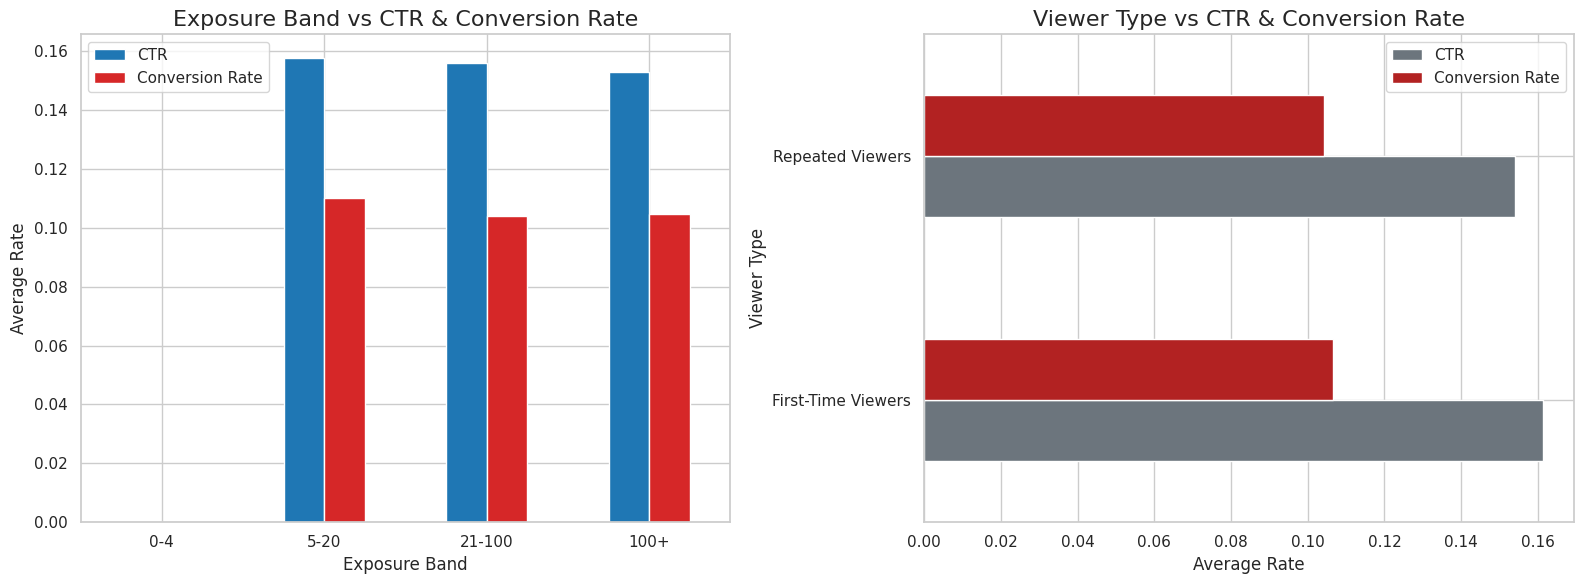

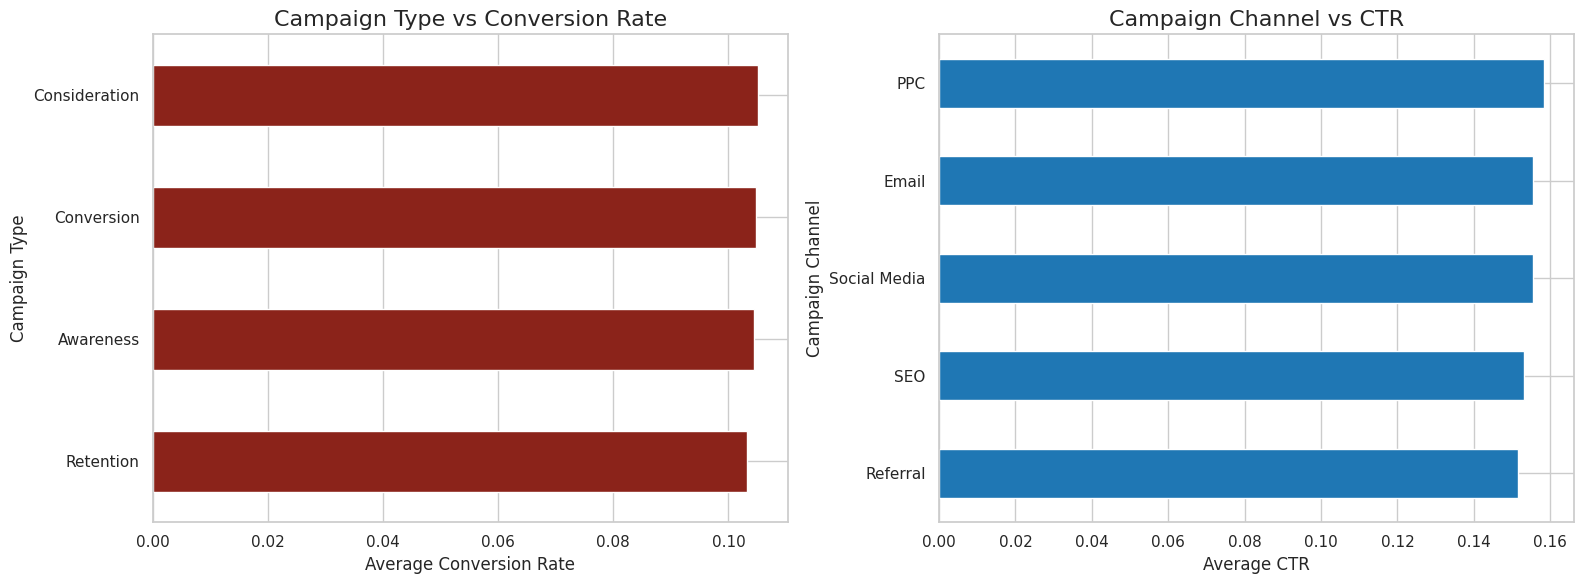

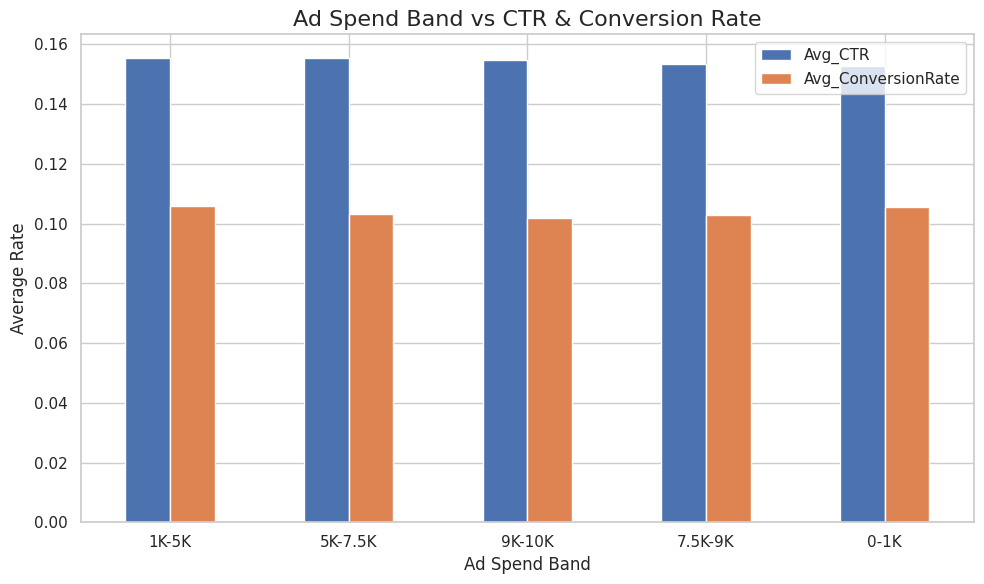

In [10]:
# Plot 1: exposure band and viewer type comparisons
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

exposure_order = ["0-4", "5-20", "21-100", "100+"]
exp_plot = (
    df.groupby("ExposureBand")[["ClickThroughRate", "ConversionRate"]]
    .mean()
    .reindex(exposure_order)
)
exp_plot.plot(kind="bar", ax=ax[0], color=["#1f77b4", "#d62728"])
ax[0].set_title("Exposure Band vs CTR & Conversion Rate")
ax[0].set_xlabel("Exposure Band")
ax[0].set_ylabel("Average Rate")
ax[0].legend(["CTR", "Conversion Rate"])
ax[0].tick_params(axis="x", rotation=0)

viewer_plot = (
    df.groupby("ViewerType")[["ClickThroughRate", "ConversionRate"]]
    .mean()
    .reindex(["First-Time Viewers", "Repeated Viewers"])
)
viewer_plot.plot(kind="barh", ax=ax[1], color=["#6c757d", "#b22222"])
ax[1].set_title("Viewer Type vs CTR & Conversion Rate")
ax[1].set_xlabel("Average Rate")
ax[1].set_ylabel("Viewer Type")
ax[1].legend(["CTR", "Conversion Rate"])

plt.tight_layout()
plt.show()

# Plot 2: campaign type and channel comparisons
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

campaign_type_summary.sort_values("Avg_ConversionRate", ascending=True)[["Avg_ConversionRate"]].plot(
    kind="barh", ax=ax[0], legend=False, color="#8b231a"
)
ax[0].set_title("Campaign Type vs Conversion Rate")
ax[0].set_xlabel("Average Conversion Rate")
ax[0].set_ylabel("Campaign Type")

channel_summary.sort_values("Avg_CTR", ascending=True)[["Avg_CTR"]].plot(
    kind="barh", ax=ax[1], legend=False, color="#1f77b4"
)
ax[1].set_title("Campaign Channel vs CTR")
ax[1].set_xlabel("Average CTR")
ax[1].set_ylabel("Campaign Channel")

plt.tight_layout()
plt.show()

# Plot 3: spend efficiency
fig, ax = plt.subplots(figsize=(10, 6))
spend_summary[["Avg_CTR", "Avg_ConversionRate"]].plot(kind="bar", ax=ax)
ax.set_title("Ad Spend Band vs CTR & Conversion Rate")
ax.set_xlabel("Ad Spend Band")
ax.set_ylabel("Average Rate")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

In [11]:
# These are the final takeaways
print("\n================ FINAL FINDINGS ================")
print("1. Best exposure range is the middle band (5-20 exposures), with stronger CTR and conversion quality")
print("2. Exposure above 100 shows diminishing returns and weaker efficiency")
print("3. Consideration campaigns perform best for conversion rate")
print("4. Retention campaigns perform best for CTR")
print("5. PPC performs best for CTR, while Social Media performs best for conversion rate")
print("6. The 1K-5K spend band is the most efficient range")
print("7. First-time viewers outperform repeated viewers")
print("================================================")


================ FINAL FINDINGS ================
1. Best exposure range is the middle band (5-20 exposures), with stronger CTR and conversion quality.
2. Exposure above 100 shows diminishing returns and weaker efficiency.
3. Consideration campaigns perform best for conversion rate.
4. Retention campaigns perform best for CTR.
5. PPC performs best for CTR, while Social Media performs best for conversion rate.
6. The 1K-5K spend band is the most efficient range.
7. First-time viewers outperform repeated viewers.


In [12]:
# Save the cleaned dataset
df.to_csv("ad_analysis_cleaned.csv", index=False)
print("Saved cleaned dataset as ad_analysis_cleaned.csv")

Saved cleaned dataset as ad_analysis_cleaned.csv
